In [1]:
import pandas as pd
from pathlib import Path
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import numpy as np
from models import BaseModel, LinearRegression, load_nn
from train import load_dataset
import torch
import xarray as xr
from tqdm.notebook import tqdm

current_dir = Path('.')
experiments_dir = current_dir / '../data/experiments'
dpi = 150
plt.rcParams.update({'font.size': 12})

In [2]:
def loss_acc(y_true, y_pred):
    cov = np.sum(y_true * y_pred)
    std_true = np.sqrt(np.sum(y_true ** 2))
    std_pred = np.sqrt(np.sum(y_pred ** 2))
    return cov / (std_true * std_pred + 1e-6)

def loss_rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def evaluate(ds, model):
    losses = []
    y_true, y_pred, lat, years = [], [], [], []

    for X_batch, y_batch, lat_batch in ds.loader:
        y_pred.append(model.predict(X_batch))
        if ds.loader_type == 'sequence' or ds.loader_type == 'sequence_map':
            y_true.append(y_batch[-1, :])
            lat.append(lat_batch[-1, :])
            X_batch = X_batch[-1, :]
        elif ds.loader_type == 'point' or ds.loader_type == 'map':
            y_true.append(y_batch)
            lat.append(lat_batch)
        if 'map' in ds.loader_type:
            B, H, W = y_true[-1].shape
            if ds.loader_type == 'map':
                year = X_batch[:, 40, 40, -2]
            else:
                year = X_batch[:, 40, 40, 15]
            year = torch.Tensor((year.numpy() * 10 + 2005).astype(np.int32))
            years.append(year.unsqueeze(1).unsqueeze(1).expand(B, H, W))
        else:
            years.append(torch.Tensor((X_batch[:, -2].numpy() * 10 + 2005).astype(np.int32)))
        if len(y_pred[-1].shape) < len(y_true[-1].shape):
            y_pred[-1] = y_pred[-1].unsqueeze(0)

    y_true, y_pred, lat, years = torch.cat(y_true).numpy(), torch.cat(y_pred).numpy(), torch.cat(lat).numpy(), torch.cat(years).numpy()
    mask = ~np.isnan(lat)
    y_true, y_pred, lat, years = y_true[mask], y_pred[mask], lat[mask], years[mask]
    weights = np.cos(np.deg2rad(lat))
    y_true *= np.sqrt(weights)
    y_pred *= np.sqrt(weights)

    acc = loss_acc(y_true, y_pred)

    rmse = []
    for year in np.unique(years):
        idx = years == year
        rmse.append((loss_rmse(y_true[idx], y_pred[idx]), year))
    rmse = np.array(rmse)

    return {
        'acc': acc,
        'rmse': np.mean(rmse[:, 0]),
        'rmse_std': np.std(rmse[:, 0]),
        'rmse_list': sorted(rmse.tolist())
    }

In [10]:
errors = []
dsTrain = load_dataset(f"swe_6_2_3_point_train")
for season, season_num in [('spring', 4), ('autum', 5), ('winter', 7)]:
    dsTest = load_dataset(f"swe_{season_num}_2_3_point_test")
    for ds_name, model_name in [('point', 'base'), ('point', 'lr'), ('point', 'point'), ('seq', 'seq'), ('map', 'map'), ('seqmap', 'seqmap'),
                               ('seqmap', 'seqmap_with_era')]:
        if model_name == 'base':
            model = BaseModel()
            model.fit(dsTest)
        elif model_name == 'lr':
            model = LinearRegression()
            model.fit(dsTrain)
        else:
            var = 3 if model_name == 'seqmap_with_era' else 2
            dsTest = load_dataset(f"swe_{season_num}_{var}_3_{ds_name}_test")  if model_name != 'point' else dsTest
            model = load_nn(f"../data/experiments/swe_etr_{model_name}_{season}")
        error = evaluate(dsTest, model)
        errors += [(season, model_name, error['acc'], error['rmse'], error['rmse_std'], error['rmse_list'])]
del dsTrain, dsTest

df = pd.DataFrame(errors, columns=['season', 'model', 'acc', 'rmse', 'rmse_std', 'rmse_list'])
df.to_csv('013_article_images_errors.csv', index=False)
print(df.pivot(index='season', columns='model', values='acc').map(lambda x: f"{x:.3f}"))
print(df.pivot(index='season', columns='model', values='rmse').map(lambda x: f"{x:.3f}"))
print(df.pivot(index='season', columns='model', values='rmse_std').map(lambda x: f"{x:.3f}"))

torch.Size([2307392])
spring point 2307392
torch.Size([2307392])
spring seq 2307392
torch.Size([4, 1000000])
torch.Size([4, 1000000])
torch.Size([4, 307392])
spring map 12
torch.Size([32, 61, 117])
torch.Size([32, 61, 117])
torch.Size([32, 61, 117])
torch.Size([32, 61, 117])
torch.Size([32, 61, 117])
torch.Size([32, 61, 117])
torch.Size([32, 61, 117])
torch.Size([32, 61, 117])
torch.Size([32, 61, 117])
torch.Size([32, 61, 117])
torch.Size([32, 61, 117])
torch.Size([32, 61, 117])
torch.Size([24, 61, 117])
spring seqmap 408
torch.Size([4, 16, 61, 117])
torch.Size([4, 16, 61, 117])
torch.Size([4, 16, 61, 117])
torch.Size([4, 16, 61, 117])
torch.Size([4, 16, 61, 117])
torch.Size([4, 16, 61, 117])
torch.Size([4, 16, 61, 117])
torch.Size([4, 16, 61, 117])
torch.Size([4, 16, 61, 117])
torch.Size([4, 16, 61, 117])
torch.Size([4, 16, 61, 117])
torch.Size([4, 16, 61, 117])
torch.Size([4, 16, 61, 117])
torch.Size([4, 16, 61, 117])
torch.Size([4, 16, 61, 117])
torch.Size([4, 16, 61, 117])
torch.Si


KeyboardInterrupt

Exception ignored in: <function CachingFileManager.__del__ at 0x7fd95bded9e0>
Traceback (most recent call last):
  File "/home/miha3009/.local/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 244, in __del__
    def __del__(self) -> None:
KeyboardInterrupt: 


In [19]:
import numpy as np
from scipy.stats import norm

# Ваши данные
r1 = 0.207   # ACC исходной модели
r2 = 0.385   # ACC новой модели
n  = 381     # размер выборки

# z-преобразование Фишера
z1 = 0.5 * np.log((1 + r1) / (1 - r1))
z2 = 0.5 * np.log((1 + r2) / (1 - r2))

# Z-статистика
Z = (z2 - z1) / np.sqrt(2 / (n - 3))

# p-value (односторонний, улучшение)
p = 1 - norm.cdf(Z)

print(f"Z = {Z:.4f}")
print(f"p = {p:.10f}")

Z = 2.6929
p = 0.0035413947


In [14]:
19.37/17.59

1.1011938601478113

In [2]:
def gen_models_df(model, ds):
    ds.add_extra('lon')
    y_preds, ys, lats, lons = [], [], [], []
    for X, y, lat in ds.loader:
        if ds.loader_type == 'point':
            y_preds.append(model.predict(X[:, :-1]))
            lons.append(X[:, -1])
            ys.append(y)
            lats.append(lat)
        elif ds.loader_type == 'sequence':
            y_preds.append(model.predict(X[:, :, :-1]))
            lons.append(X[-1, :, -1])
            ys.append(y[-1, :])
            lats.append(lat[-1, :])
    ds.remove_extra('lon')

    df = pd.DataFrame({
        'y': np.concatenate(ys),
        'y_pred': np.concatenate(y_preds),
        'lat': np.concatenate(lats),
        'lon': np.concatenate(lons)
    })
    return df

def calculate_metrics(group):
    y, p = group['y'].values, group['y_pred'].values
    mask = ~np.isnan(y) & ~np.isnan(p)
    y, p = y[mask], p[mask]
    
    if len(y) < 2:
        return pd.Series([np.nan], index=['corr'])

    with np.errstate(invalid='ignore', divide='ignore'):
        try:
            corr = np.corrcoef(y, p)[0,1]
        except:
            corr = np.nan

    return pd.Series([corr], index=['corr'])

def calculate_spatial_metrics(model, ds, lats, lons):
    y_pred, y_true = [], []
    ds.add_extra('lon')
    ds.remove_extra('lon')
    for X_batch, y_batch, _ in ds.loader:
        y_pred.append(model.predict(X_batch))
        if ds.loader_type == 'sequence_map':
            y_true.append(y_batch[-1, :, :, :])
        else:
            y_true.append(y_batch)
        if len(y_pred[-1].shape) < len(y_true[-1].shape):
            y_pred[-1] = y_pred[-1].unsqueeze(0)

    y_true, y_pred = torch.cat(y_true), torch.cat(y_pred)

    y_pred_centered = y_pred - torch.mean(y_pred, dim=0, keepdim=True)
    y_true_centered = y_true - torch.mean(y_true, dim=0, keepdim=True)
    cov = torch.mean(y_pred_centered * y_true_centered, dim=0)
    std_pred = torch.std(y_pred, dim=0)
    std_true = torch.std(y_true, dim=0)
    corr_map = cov / (std_pred * std_true + 1e-6)

    df = pd.DataFrame({
        'lat': np.repeat(lats, len(lons)),
        'lon': np.tile(lons, len(lats)),
        'corr': corr_map.flatten().numpy()
    })
    
    return df

In [3]:
dsTest = load_dataset(f"swe_7_2_3_point_test")
lats = dsTest.lat
lons = dsTest.lon

basemodel = BaseModel()
basemodel.fit(dsTest)
df = gen_models_df(basemodel, dsTest)
df = df.groupby(['lat', 'lon']).apply(calculate_metrics, include_groups=False).reset_index()
basecorr = df.pivot(index='lat', columns='lon', values='corr').reindex(index=lats, columns=lons)

modelcorrs = []
for model_name in ['point', 'seq', 'map', 'seqmap']:
    print(model_name)
    dsTest = load_dataset(f"swe_7_2_3_{model_name}_test")
    model = load_nn(f"../data/experiments/swe_etr_{model_name}_winter")
    if dsTest.loader_type == 'map' or dsTest.loader_type == 'sequence_map':
        df = calculate_spatial_metrics(model, dsTest, lats, lons)
    else:
        df = gen_models_df(model, dsTest)
        df = df.groupby(['lat', 'lon']).apply(calculate_metrics, include_groups=False).reset_index()
    modelcorrs.append(df.pivot(index='lat', columns='lon', values='corr').reindex(index=lats, columns=lons))

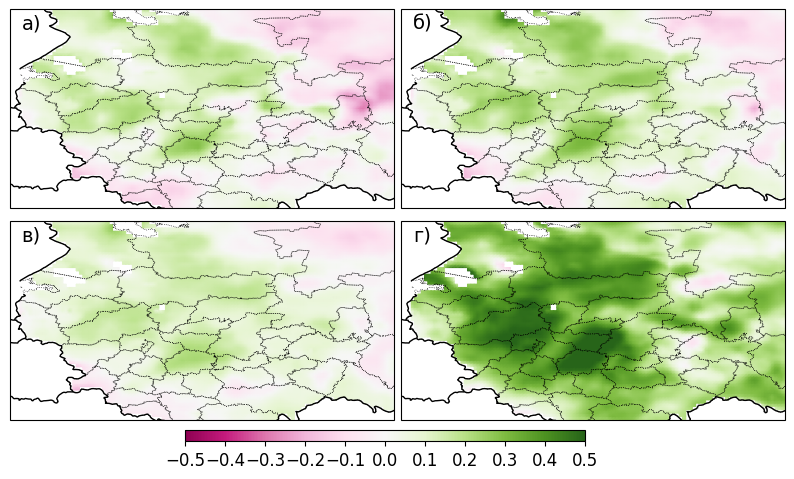

In [4]:
def draw_swe_map(ax, data, label, vmin, vmax, cmap='PiYG'):
    minlon, minlat, maxlon, maxlat = 27, 50, 56, 65
    lons = np.arange(minlon, maxlon+0.1, 0.25)
    lats = np.arange(minlat, maxlat+0.1, 0.25)
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    
    ax.set_extent([minlon, maxlon, minlat, maxlat], ccrs.PlateCarree())
    
    mesh = ax.pcolormesh(lon_grid, lat_grid, data, cmap=cmap, vmin=vmin, vmax=vmax,
                         shading='gouraud', rasterized=True)
    
    ax.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)
    gdf = gpd.read_file('../data/raw/time_invariant/ne_10m_admin_1_states_provinces.zip')
    russia_regions = gdf[gdf['admin'] == 'Russia']
    ax.add_geometries(russia_regions.geometry, crs=ccrs.PlateCarree(),
                      edgecolor='k', facecolor='none', linewidth=0.5, linestyle=':', zorder=3)
    ax.text(0.03, 0.9, label, transform=ax.transAxes, fontsize=14)
    return mesh

def plot_swe_corr(datasets):
    fig, axes = plt.subplots(2, 2, figsize=(10, 5.6), gridspec_kw={'wspace': 0.02, 'hspace': 0.02},
                        subplot_kw={'projection': ccrs.PlateCarree()})
    axes = axes.flatten()
    labels = ['a)', 'б)', 'в)', 'г)']

    meshes = []
    for i, ax in enumerate(axes):
        meshes.append(draw_swe_map(ax, datasets[i], labels[i], -0.5, 0.5))

    fig.subplots_adjust(bottom=0.13)
    cbar_ax = fig.add_axes([0.3, 0.1, 0.4, 0.02])
    cbar = fig.colorbar(meshes[0], cax=cbar_ax, orientation='horizontal', ticks=np.arange(-0.5, 0.51, 0.1))
    plt.savefig(f'../figures/article/1.png', dpi=dpi, bbox_inches='tight')
    plt.show()

plot_swe_corr([corr.to_numpy() - basecorr.to_numpy() for corr in modelcorrs])

In [5]:
def load_all_df(season, season_num):
    dfs = []

    X, y, lat = load_dataset(f"swe_{season_num}_2_3_point_test").load_all()
    data = torch.cat([y.reshape(-1, 1), X[:, 0].reshape(-1, 1), X[:, -1].reshape(-1, 1), lat.reshape(-1, 1)], dim=1)
    dfs.append(pd.DataFrame(data, columns=(['era5', 'swe', 'lead_time', 'lat'])))
    model = load_nn(f"../data/experiments/swe_etr_point_{season}")
    y_pred = model.predict(X)
    data = torch.cat([y.reshape(-1, 1), y_pred.reshape(-1, 1), X[:, -1].reshape(-1, 1), lat.reshape(-1, 1)], dim=1)
    dfs.append(pd.DataFrame(data, columns=(['era5', 'swe', 'lead_time', 'lat'])))

    X, y, lat = load_dataset(f"swe_{season_num}_2_3_seq_test").load_all()
    model = load_nn(f"../data/experiments/swe_etr_seq_{season}")
    y_pred = model.predict(X)
    data = torch.cat([y[-1, :].reshape(-1, 1), y_pred.reshape(-1, 1), X[-1, :, -1].reshape(-1, 1), lat[-1, :].reshape(-1, 1)], dim=1)
    dfs.append(pd.DataFrame(data, columns=(['era5', 'swe', 'lead_time', 'lat'])))

    X, y, lat = load_dataset(f"swe_{season_num}_2_3_map_test").load_all()
    model = load_nn(f"../data/experiments/swe_etr_map_{season}")
    y_pred = model.predict(X)
    data = torch.cat([y.reshape(-1, 1), y_pred.reshape(-1, 1), X[:, :, :, -1].reshape(-1, 1), lat.reshape(-1, 1)], dim=1)
    dfs.append(pd.DataFrame(data, columns=(['era5', 'swe', 'lead_time', 'lat'])))

    X, y, lat = load_dataset(f"swe_{season_num}_2_3_seqmap_test").load_all()
    model = load_nn(f"../data/experiments/swe_etr_seqmap_{season}")
    y_pred = model.predict(X)
    data = torch.cat([y[-1, :, :, :].reshape(-1, 1), y_pred.reshape(-1, 1), X[-1, :, :, :, -1].reshape(-1, 1), lat[-1, :, :, :].reshape(-1, 1)], dim=1)
    dfs.append(pd.DataFrame(data, columns=(['era5', 'swe', 'lead_time', 'lat'])))

    ds = load_dataset(f"swe_{season_num}_3_3_seqmap_test")
    X, y, lat = ds.load_all()
    model = load_nn(f"../data/experiments/swe_etr_seqmap_with_era_{season}")
    y_pred = model.predict(X)
    data = torch.cat([y[-1, :, :, :].reshape(-1, 1), y_pred.reshape(-1, 1), X[-1, :, :, :, -1].reshape(-1, 1), lat[-1, :, :, :].reshape(-1, 1)], dim=1)
    dfs.append(pd.DataFrame(data, columns=(['era5', 'swe', 'lead_time', 'lat'])))

    return dfs

In [6]:
df_spring = load_all_df('spring', 4)
df_autum = load_all_df('autum', 5)
df_winter = load_all_df('winter', 7)

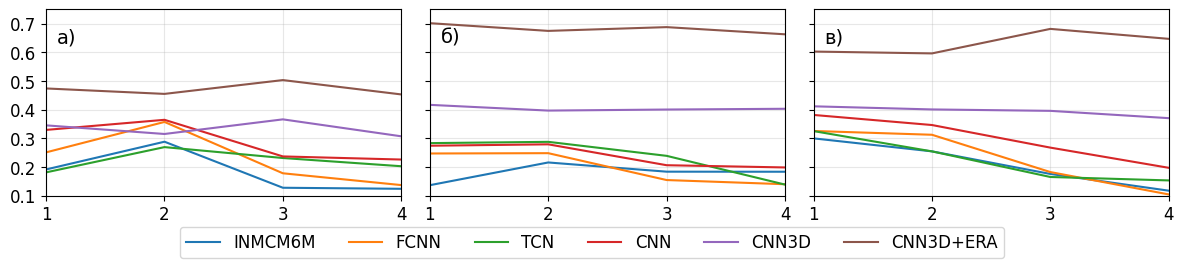

In [7]:
dfss = [df_autum, df_winter, df_spring]

fig, axes = plt.subplots(1, 3, figsize=(12, 2.5), sharey=True)
y_ticks = np.arange(0.1, 0.8, 0.1)
y_labels = ['0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7']
x_ticks = [1, 2, 3, 4]
titles = ['а)', 'б)', 'в)']
lines = []
labels = []

for (ax, dfs, title) in zip(axes, dfss, titles):
    for df, name in zip(dfs, ['INMCM6M', 'FCNN', 'TCN', 'CNN', 'CNN3D', 'CNN3D+ERA']):
        corr = df.groupby('lead_time').apply(
            lambda x: x['swe'].corr(x['era5']),
            include_groups=False
        ).reset_index(name='corr')
        line = ax.plot(corr['lead_time']+1, corr['corr'], label=name)
        if ax == axes[0]:
            lines.append(line[0])
            labels.append(name)
    ax.text(0.03, 0.82, title, transform=ax.transAxes, fontsize=14)
    ax.set_ylim([0.1, 0.75])
    ax.set_yticks(y_ticks)
    ax.set_xlim([1, 4])
    ax.set_xticks(x_ticks)
    ax.grid(True, alpha=0.3)
fig.legend(lines, labels, loc='lower center', bbox_to_anchor=(0.5, -0.1), 
           ncol=6, fontsize=12, frameon=True)
plt.tight_layout()
plt.savefig('../figures/article/2.png', dpi=dpi, bbox_inches='tight')
plt.show()

In [3]:
def load_df(season, season_num):
    X, _, _ = load_dataset(f"swe_{season_num}_6_3_seqmap_test").load_all()
    lats = X[-1, :, :, :, 0].reshape(-1, 1)
    lons = X[-1, :, :, :, 1].reshape(-1, 1)
    lead_times = X[-1, :, :, :, 2].reshape(-1, 1)

    ds = load_dataset(f"swe_{season_num}_2_3_seqmap_test")
    ds2 = load_dataset(f"swe_{season_num}_3_3_seqmap_test")
    X, y, _ = ds.load_all()
    X2, _, _ = ds2.load_all()
    model = load_nn(f"../data/experiments/swe_etr_seqmap_{season}")
    model2 = load_nn(f"../data/experiments/swe_etr_seqmap_with_era_{season}")
    y_pred = model.predict(X)
    y2_pred = model2.predict(X2)
    data = torch.cat([y[-1, :, :, :].reshape(-1, 1), y_pred.reshape(-1, 1), y2_pred.reshape(-1, 1), X[-1, :, :, :, 0].reshape(-1, 1),
                  lead_times, lats, lons, X[-1, :, :, :, -2].reshape(-1, 1)], dim=1)
    df = pd.DataFrame(data, columns=(['era5', 'swe', 'swe_era', 'swe_old', 'lead_time', 'lat', 'lon', 'year']))
    ds = xr.open_dataset('../data/train/swe/std.nc', engine='h5netcdf')
    df_std = ds['swe'].to_dataframe().reset_index().rename(columns={'swe': 'std'})
    df = df.merge(df_std, on=['lat', 'lon'])
    df['swe_old'] *= df['std']
    df['year'] = df['year']*10 + 2005
    df['diff'] = df['swe'] - df['swe_old']
    df['diff_era'] = df['era5'] - df['swe_old']
    df['diff_swe_era'] = df['swe_era'] - df['swe_old']
    return df

def draw_swe_map(ax, data, label, vmin, vmax, cmap='RdBu_r'):
    minlon, minlat, maxlon, maxlat = 27, 50, 56, 65
    lons = np.arange(minlon, maxlon+0.1, 0.25)
    lats = np.arange(minlat, maxlat+0.1, 0.25)
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    data = data.pivot(index='lat', columns='lon', values='diff').reindex(index=lats, columns=lons)

    ax.set_extent([minlon, maxlon, minlat, maxlat], ccrs.PlateCarree())
    
    mesh = ax.pcolormesh(lon_grid, lat_grid, -data, cmap=cmap, vmin=vmin, vmax=vmax,
                         shading='gouraud', rasterized=True)
    
    ax.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)
    gdf = gpd.read_file('../data/raw/time_invariant/ne_10m_admin_1_states_provinces.zip')
    russia_regions = gdf[gdf['admin'] == 'Russia']
    ax.add_geometries(russia_regions.geometry, crs=ccrs.PlateCarree(),
                      edgecolor='k', facecolor='none', linewidth=0.5, linestyle=':', zorder=3)
    ax.text(0.03, 0.85, label, transform=ax.transAxes, fontsize=14)
    return mesh

def plot_swe_map(dataset):
    fig, axes = plt.subplots(3, 3, figsize=(12, 6.7), subplot_kw={'projection': ccrs.PlateCarree()}, gridspec_kw={'wspace': 0.02, 'hspace': 0.02})
    for i in range(3):
        for j in range(3):
            mesh = draw_swe_map(axes[i][j], dataset[i][j], str(i*3+j+1), -30, 30)
    fig.subplots_adjust(bottom=0.13)
    cbar_ax = fig.add_axes([0.3, 0.1, 0.4, 0.02])
    cbar = fig.colorbar(mesh, cax=cbar_ax, orientation='horizontal', ticks=np.arange(-30, 31, 5))
    plt.savefig(f'../figures/article/3.png', dpi=dpi, bbox_inches='tight')
    plt.show()

dfs = []
for season, season_num in zip(['autum', 'winter', 'spring'], [5, 4, 7]):
    df = load_df(season, season_num)
    df = df[df['year'] == 2025]
    diff = df.groupby(['lat', 'lon'])['diff'].mean().reset_index()
    diff_era = df.groupby(['lat', 'lon'])['diff_era'].mean().reset_index().rename(columns={'diff_era': 'diff'})
    diff_swe_era = df.groupby(['lat', 'lon'])['diff_swe_era'].mean().reset_index().rename(columns={'diff_swe_era': 'diff'})
    dfs.append([diff, diff_swe_era, diff_era])

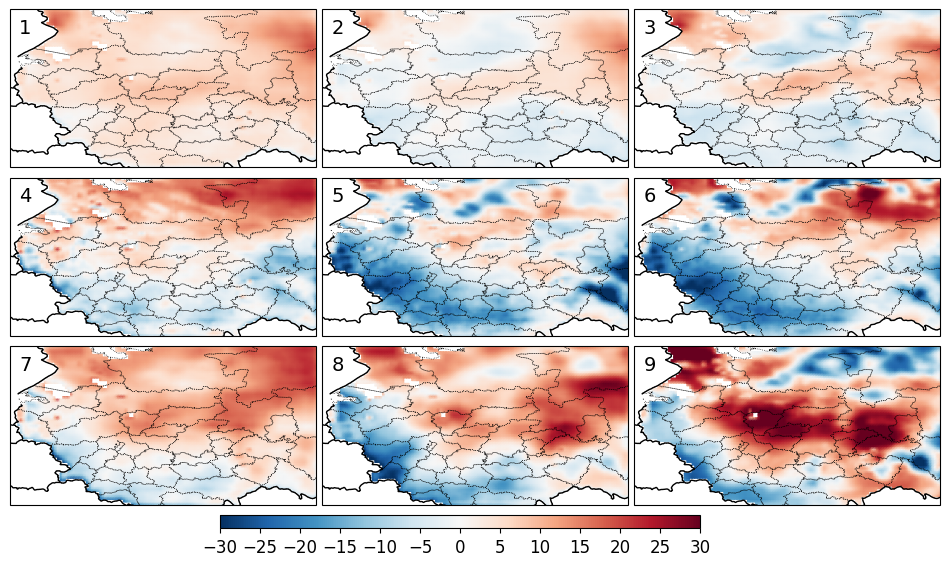

In [4]:
plot_swe_map(dfs)

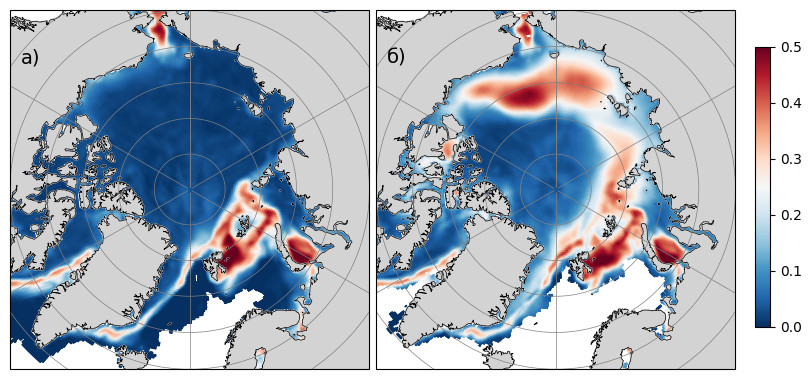

In [24]:
def draw_ice_map(ax, data, label, cmap='RdBu_r'):
    lats = np.arange(40, 90.25, 0.25)
    lons = np.arange(-180, 180, 0.25)
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    ax.set_extent([-180, 180, 65, 90], ccrs.PlateCarree())
    mesh = ax.pcolormesh(lon_grid, lat_grid, data, transform=ccrs.PlateCarree(), cmap=cmap,
                     vmin=0, vmax=0.5, shading='gouraud', rasterized=True)
    ax.add_feature(cfeature.LAND, color='lightgray', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=2)
    gl = ax.gridlines(linewidth=0.5, color='gray')
    ax.text(0.03, 0.85, label, transform=ax.transAxes, fontsize=14)
    return mesh

fig, axes = plt.subplots(1, 2, figsize=(10, 5.6), gridspec_kw={'wspace': 0.02, 'hspace': 0.02},
                        subplot_kw={'projection': ccrs.NorthPolarStereo()})

meshes = []
for ax, label, season in zip(axes, ['а)', 'б)'], ['spring', 'autum']):
    base_rmse_df = pd.read_csv(experiments_dir / f'aice_base_{season}_rmse.csv').drop(columns=['lat']).to_numpy()
    meshes.append(draw_ice_map(ax, base_rmse_df, label))

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.87, 0.25, 0.015, 0.5])
cbar = fig.colorbar(meshes[0], cax=cbar_ax, orientation='vertical', ticks=np.arange(0, 0.51, 0.1))

plt.savefig(f'../figures/article/img1.png', dpi=dpi, bbox_inches='tight')
plt.show()

In [2]:
from datetime import datetime
from shapely.geometry import box
import pickle

dates = pd.date_range(f"2001-01-01", f"2001-12-30", freq="D")
weeks = {}

week_num = 1
day_count = 0
for ts in dates:
    key = f"{ts.month:02d}{ts.day:02d}"
    if week_num not in weeks:
        weeks[week_num] = []
    weeks[week_num].append(ts)
    day_count += 1
    if day_count == 7:
        week_num += 1
        day_count = 0
for num in weeks:
    weeks[num] = weeks[num][3]

etr_bbox = box(27, 50, 56, 65)
minlon, minlat, maxlon, maxlat = etr_bbox.bounds
lons = np.arange(minlon, maxlon+0.1, 0.25)
lats = np.arange(minlat, maxlat+0.1, 0.25)

result = []

for season, season_num in [('winter', 6)]: #[('spring', 4), ('autum', 5), ('winter', 7)]:
    dsTest = load_dataset(f"swe_{season_num}_3_3_seqmap_test")
    model = load_nn(f"../data/experiments/swe_etr_seqmap_with_era_{season}")
    
    X, _, _ = dsTest.load_all()
    y = X[-1, :, :, :, 0].numpy() * dsTest.std['swe']
    y_pred = model.predict(X).numpy()
    cos = X[-1, :, 40, 40, 13].numpy()
    sin = X[-1, :, 40, 40, 14].numpy()
    years = (X[-1, :, 40, 40, 15].numpy() * 10 + 2005).astype(np.int32)
    weeks_num = np.round(((np.atan2(sin, cos) / (np.pi * 2) + 1) * 52) % 52 + 1).astype(np.int32)
    lead_time = X[-1, :, 40, 40, -1]
    dates = []
    for num, year in zip(weeks_num, years):
        week = weeks.get(num)
        dates.append(datetime(int(year), week.month, week.day))
    for i in range(len(dates)):
        y_pred[i, :, :] += dsTest.climate[weeks_num[i]].reshape(X.shape[2:4])
        y[i, :, :] += dsTest.climate[weeks_num[i]].reshape(X.shape[2:4])
    print(np.min(y), np.min(y_pred))
    mask = lead_time == 1
    result.append({'dates': np.array(dates)[mask], 'forecast': y_pred[mask, :, :], 'source': y[mask, :, :], 'lats': lats, 'lons': lons})

with open('/home/miha3009/work/weather/station_snow/forecast_result.pkl', 'wb') as f:
    pickle.dump(result, f)

-3.8146973e-06 -52.419857


In [13]:
X[-1, :, 40, 40, -1]

tensor([0., 1., 2.,  ..., 1., 2., 3.])